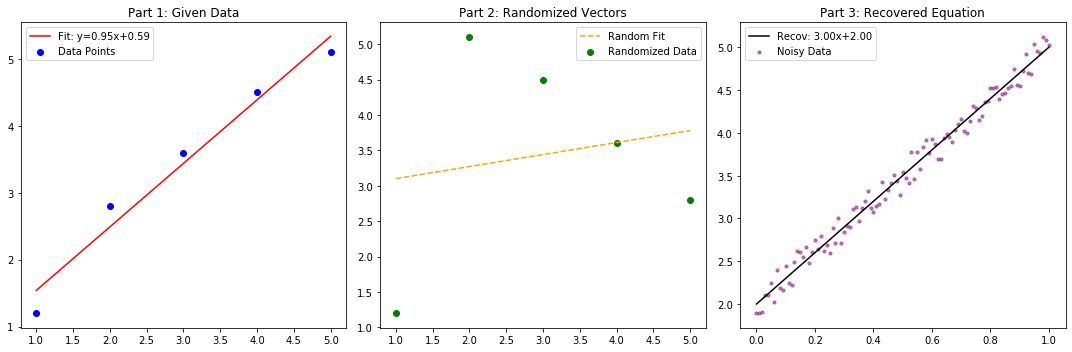

Part 1 - Slope: 0.95, Intercept: 0.59
Part 3 - Recovered Slope: 3.00, Intercept: 2.00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Least Squares Fit (Given Data)
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones for the intercept
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

# Plotting Part 1
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, m*X + c, color='red', label=f'Fit: y={m:.2f}x+{c:.2f}')
plt.title("Part 1: Given Data")
plt.legend()

# Randomized Vectors
# shuffle Y values to break the linear relationship
Y_rand = np.random.permutation(Y)
m_rand, c_rand = np.linalg.lstsq(A, Y_rand, rcond=None)[0]

# Plotting Part 2
plt.subplot(1, 3, 2)
plt.scatter(X, Y_rand, color='green', label='Randomized Data')
plt.plot(X, m_rand*X + c_rand, color='orange', linestyle='--', label='Random Fit')
plt.title("Part 2: Randomized Vectors")
plt.legend()

# Custom Equation + noise
# Original Equation: y = 3x + 2
X_fine = np.arange(0, 1.01, 0.01)
# Add random noise between -0.2 and 0.2
noise = np.random.uniform(-0.2, 0.2, len(X_fine))
Y_noisy = 3 * X_fine + 2 + noise

# Re-run Least Squares on noisy data
A_fine = np.vstack([X_fine, np.ones(len(X_fine))]).T
m_final, c_final = np.linalg.lstsq(A_fine, Y_noisy, rcond=None)[0]

# Plotting Part 3
plt.subplot(1, 3, 3)
plt.scatter(X_fine, Y_noisy, s=10, color='purple', alpha=0.5, label='Noisy Data')
plt.plot(X_fine, m_final*X_fine + c_final, color='black', label=f'Recov: {m_final:.2f}x+{c_final:.2f}')
plt.title("Part 3: Recovered Equation")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Part 1 - Slope: {m:.2f}, Intercept: {c:.2f}")
print(f"Part 3 - Recovered Slope: {m_final:.2f}, Intercept: {c_final:.2f}")